## 02 - Preprocess and Label Captured IQ Bursts

This notebook loads IQ bursts captured by PlutoSDR, matches them to BLE devices seen by the Raspberry Pi scanner, and saves a labeled dataset for training or analysis.

In [22]:
# Setup path and load utils
import sys, os
sys.path.append(os.path.abspath("../src"))
from utils import list_npys_by_timestamp
from labeling import match_bursts_to_ble_devices
import pandas as pd
from datetime import datetime
from utils import parse_timestamp
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
print("Current working directory:", os.getcwd())
print("Available files/folders in ../data:")
print(os.listdir("../data"))
# List IQ burst files and extract timestamps
burst_folder = "../data/raw"
ble_log_path = "../data/ble_log.csv"

burst_files = list_npys_by_timestamp(burst_folder)
burst_timestamps = [ts.isoformat() for _, ts in burst_files]

print(f"Found {len(burst_timestamps)} IQ burst files.")

# Parse timestamp correctly (if there's a 'Z' at the end, remove it)
def parse_timestamp(ts):
    return datetime.fromisoformat(ts.replace("Z", "")) if ts.endswith("Z") else datetime.fromisoformat(ts)

# Load BLE log and check if it's populated
df_ble = pd.read_csv("../data/ble_log.csv")
print("?? BLE log preview:")
print(df_ble.tail())

# Confirm burst time range
print("?? Burst timestamps range:")
print("Start:", burst_timestamps[0])
print("End  :", burst_timestamps[-1])

# Confirm BLE log time range
print("?? BLE log timestamp range:")
print("Start:", df_ble['timestamp'].iloc[0])
print("End  :", df_ble['timestamp'].iloc[-1])

# Try matching bursts to BLE devices with wider time window
matches = match_bursts_to_ble_devices(
    burst_timestamps,
    ble_log_path=ble_log_path,
    time_window=2.0
)

# Show results
df_matches = pd.DataFrame(matches)
print("?? Matches:")
print(df_matches.head())

Current working directory: /home/isesdr/Downloads/ble-RFFingerprinting/notebooks
Available files/folders in ../data:
['raw', 'ble_log.csv']


Found 124195 IQ burst files.
?? BLE log preview:
                 timestamp                mac  rssi
2122  2025-04-21T23:13:34Z  88:c6:26:3f:3b:75   -83
2123  2025-04-21T23:13:38Z  88:c6:26:3f:3b:75   -87
2124  2025-04-21T23:13:44Z  88:c6:26:3f:3b:75   -84
2125  2025-04-21T23:13:49Z  88:c6:26:3f:3b:75   -84
2126  2025-04-21T23:13:55Z  88:c6:26:3f:3b:75   -87
?? Burst timestamps range:
Start: 2025-04-21T22:19:46.259036
End  : 2025-04-21T23:14:03.578790
?? BLE log timestamp range:
Start: 2025-04-21T22:19:44Z
End  : 2025-04-21T23:13:55Z
?? Matches:
              burst_timestamp         matched_macs  \
0  2025-04-21T22:19:46.259036  [88:c6:26:3f:3b:75]   
1  2025-04-21T22:19:46.305652  [88:c6:26:3f:3b:75]   
2  2025-04-21T22:19:46.321397  [88:c6:26:3f:3b:75]   
3  2025-04-21T22:19:46.342234  [88:c6:26:3f:3b:75]   
4  2025-04-21T22:19:46.371978  [88:c6:26:3f:3b:75]   

                   matched_rssi  
0  {'88:c6:26:3f:3b:75': -86.0}  
1  {'88:c6:26:3f:3b:75': -86.0}  
2  {'88:c6:26:3f:3b:7

? 123963 / 124195 bursts matched at least one BLE device.
[('88:c6:26:3f:3b:75', 123963), ('1f:6e:49:0c:d3:8d', 1006), ('1f:6e:49:0c:d3:8e', 6), ('1f:6e:49:0c:d3:8c', 3)]


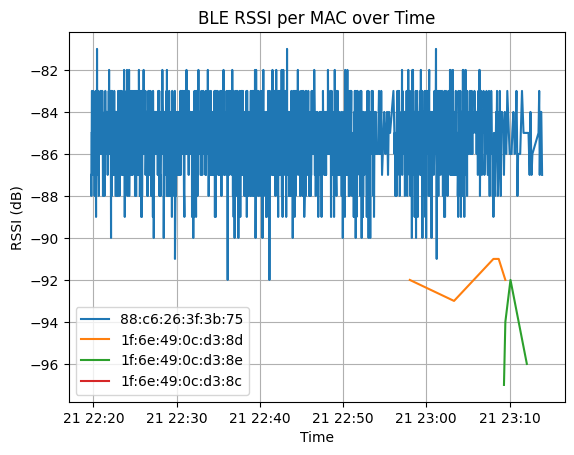

/tmp/ipykernel_3788/3802791381.py:37: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  density = burst_times.dt.floor("1S").value_counts().sort_index()


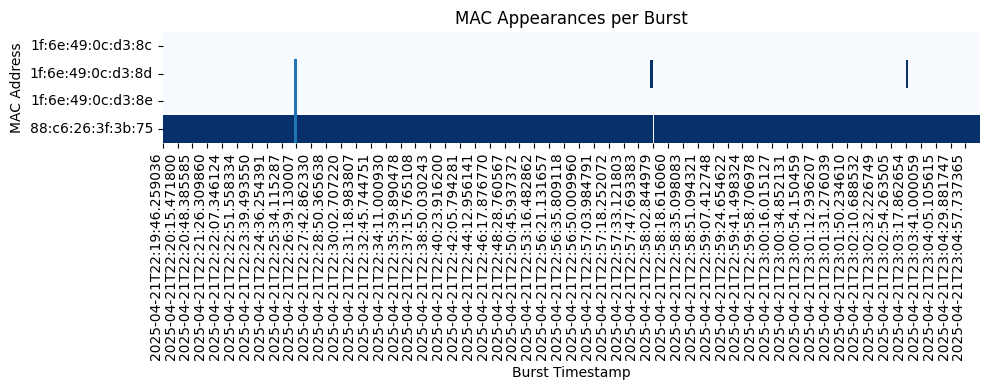

In [23]:
total_bursts = len(df_matches)
with_ble = sum(len(macs) > 0 for macs in df_matches["matched_macs"])
print(f"? {with_ble} / {total_bursts} bursts matched at least one BLE device.")

from collections import Counter
all_macs = sum(df_matches['matched_macs'].tolist(), [])
mac_counts = Counter(all_macs)
print(mac_counts.most_common(10))  # Top 10

rssi_per_mac = {}
for rssi_dict in df_matches['matched_rssi']:
    for mac, rssi in rssi_dict.items():
        rssi_per_mac.setdefault(mac, []).append(rssi)

avg_rssi = {mac: sum(rssis)/len(rssis) for mac, rssis in rssi_per_mac.items()}
pd.Series(avg_rssi).sort_values(ascending=False).head(10)

df_matches.to_csv("../data/labeled_bursts.csv", index=False)


if df_ble['timestamp'].dtype == 'object':
    df_ble['timestamp'] = df_ble['timestamp'].apply(parse_timestamp)


for mac in df_ble['mac'].unique():
    subset = df_ble[df_ble['mac'] == mac]
    plt.plot(subset['timestamp'], subset['rssi'], label=mac)

plt.legend()
plt.title("BLE RSSI per MAC over Time")
plt.xlabel("Time")
plt.ylabel("RSSI (dB)")
plt.grid(True)
plt.show()

burst_times = pd.to_datetime(df_matches['burst_timestamp'])
density = burst_times.dt.floor("1S").value_counts().sort_index()
density.plot(title="SDR Burst Density", figsize=(10, 4))

# Create a binary matrix: rows = bursts, cols = MACs
macs = sorted(set(m for mlist in df_matches["matched_macs"] for m in mlist))
heatmap = pd.DataFrame(0, index=df_matches["burst_timestamp"], columns=macs)

for idx, row in df_matches.iterrows():
    for mac in row["matched_macs"]:
        heatmap.at[row["burst_timestamp"], mac] = 1

sns.heatmap(heatmap.T, cmap="Blues", cbar=False)
plt.title("MAC Appearances per Burst")
plt.xlabel("Burst Timestamp")
plt.ylabel("MAC Address")
plt.tight_layout()
plt.show()
